# Chapter 7 — Computational Experiments

> **Prerequisites:** ch001–ch006
>
> **You will learn:**
> - How to design a computational experiment: hypothesis, controls, measurement, interpretation
> - The difference between an experiment and a demonstration
> - How to measure something you cannot observe directly via proxy metrics
> - Common pitfalls: confirmation bias, overfitting an experiment, ignoring variance
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

A **demonstration** shows that something works in one case. An **experiment** measures how and why it works — or doesn't — across systematically varied conditions.

Most programmers write demonstrations. They run their algorithm on a test input, see it produce the right output, and conclude it is correct. A mathematician (and a scientist) runs *experiments*: vary the input systematically, measure the outcome, control for confounders, and draw quantified conclusions.

Computational experiments apply the scientific method to mathematical and algorithmic questions:
1. **Hypothesis:** a precise, falsifiable claim
2. **Design:** which variables to vary, which to hold fixed, how to measure the outcome
3. **Execution:** run the experiment, collect data
4. **Analysis:** quantify the result, estimate uncertainty
5. **Conclusion:** what the data supports — and what it does not

**Common misconception:** A successful run proves an algorithm correct.

One run proves nothing. It is consistent with correctness. Experiments that vary inputs, stress edge cases, and measure failure rates build genuine evidence.

## 2. Intuition & Mental Models

**Physical analogy:** Drug trials. A single patient recovering after taking a drug proves nothing — they might have recovered anyway. A randomized controlled trial with 1000 patients, a placebo group, and blinded measurement produces evidence. The same distinction applies to algorithm testing.

**Computational analogy:** A/B testing in production. You don't deploy a new feature and ask "did revenue go up?" — you run a controlled experiment with a random split, measure the difference, and compute a confidence interval. Computational experiments apply the same discipline to mathematical questions.

Recall from ch004 *(Mathematical Curiosity and Exploration)*: we used `test_conjecture` to check claims on random inputs. That was the embryo of an experiment. This chapter formalizes the design.

## 3. Visualization

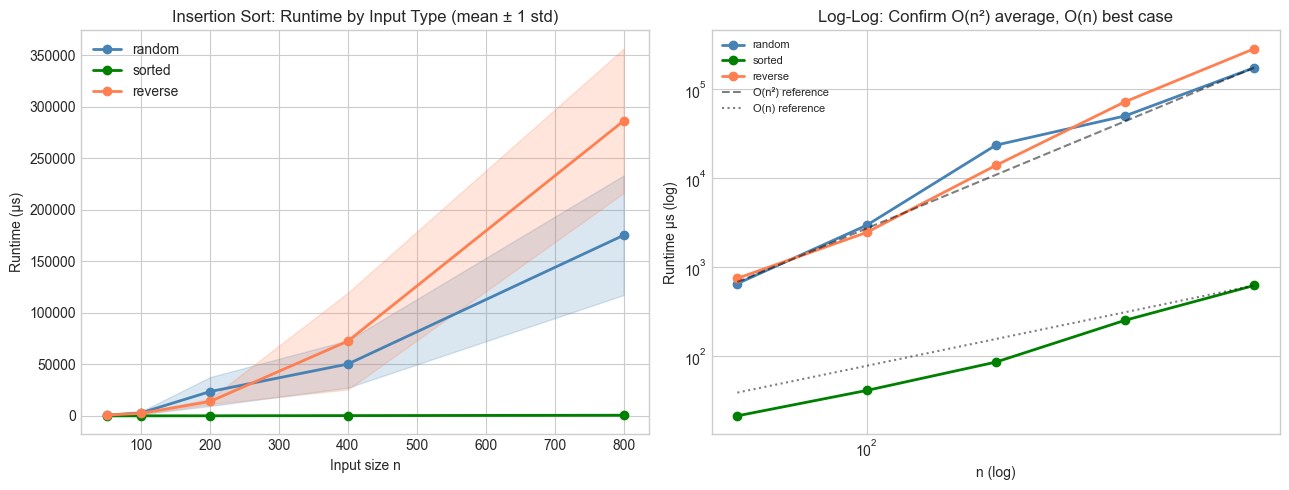

In [1]:
# --- Visualization: Algorithm runtime experiment with variance ---
# A proper experiment measures not just mean runtime but distribution.
import numpy as np
import matplotlib.pyplot as plt
import time
plt.style.use('seaborn-v0_8-whitegrid')

def insertion_sort(arr):
    a = arr.copy()
    for i in range(1, len(a)):
        key, j = a[i], i - 1
        while j >= 0 and a[j] > key:
            a[j+1] = a[j]; j -= 1
        a[j+1] = key
    return a

N_SIZES = [50, 100, 200, 400, 800]
N_REPS = 30
INPUT_TYPES = {'random': lambda n: np.random.permutation(n),
               'sorted': lambda n: np.arange(n),
               'reverse': lambda n: np.arange(n)[::-1]}

results = {t: {n: [] for n in N_SIZES} for t in INPUT_TYPES}

for input_type, gen in INPUT_TYPES.items():
    for n in N_SIZES:
        for _ in range(N_REPS):
            arr = gen(n)
            t0 = time.perf_counter()
            insertion_sort(arr)
            results[input_type][n].append(time.perf_counter() - t0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'random': 'steelblue', 'sorted': 'green', 'reverse': 'coral'}
for input_type, color in colors.items():
    means = [np.mean(results[input_type][n]) * 1e6 for n in N_SIZES]
    stds  = [np.std(results[input_type][n])  * 1e6 for n in N_SIZES]
    axes[0].plot(N_SIZES, means, 'o-', color=color, label=input_type, linewidth=2)
    axes[0].fill_between(N_SIZES,
                          [m-s for m,s in zip(means,stds)],
                          [m+s for m,s in zip(means,stds)],
                          alpha=0.2, color=color)

axes[0].set_xlabel('Input size n'); axes[0].set_ylabel('Runtime (μs)')
axes[0].set_title('Insertion Sort: Runtime by Input Type (mean ± 1 std)')
axes[0].legend()

# Log-log to check O(n²) scaling
for input_type, color in colors.items():
    means = [np.mean(results[input_type][n]) * 1e6 for n in N_SIZES]
    axes[1].loglog(N_SIZES, means, 'o-', color=color, label=input_type, linewidth=2)

n_ref = np.array(N_SIZES, dtype=float)
axes[1].loglog(n_ref, n_ref**2 / n_ref[-1]**2 * np.mean(results['random'][N_SIZES[-1]]) * 1e6,
               'k--', alpha=0.5, label='O(n²) reference')
axes[1].loglog(n_ref, n_ref / n_ref[-1] * np.mean(results['sorted'][N_SIZES[-1]]) * 1e6,
               'k:', alpha=0.5, label='O(n) reference')
axes[1].set_xlabel('n (log)'); axes[1].set_ylabel('Runtime μs (log)')
axes[1].set_title('Log-Log: Confirm O(n²) average, O(n) best case')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

A computational experiment measures a *quantity* $M$ as a function of *parameter* $P$, while holding *controls* $C$ fixed.

**Formal structure:**
- $P$ = independent variable (what we vary)
- $M(P)$ = measurement function (what we observe)
- $\hat{M}(P)$ = estimated expected value from $k$ replications: $\hat{M}(P) = \frac{1}{k}\sum_{i=1}^k M_i(P)$
- $\sigma(P)$ = standard deviation across replications

The **signal-to-noise ratio** of an experiment is $\hat{M}(P) / \sigma(P)$. If this is $< 1$, the measurement is dominated by noise — you cannot draw conclusions.

**Scaling hypothesis:** If we claim $M(P) = O(P^\alpha)$, then on a log-log plot, the slope should be $\alpha$. This gives a quantitative test for algorithmic complexity claims.

In [2]:
# --- Implementation: Experiment framework ---
import numpy as np
import time

def run_experiment(algorithm, input_generator, param_values, n_reps=20):
    """
    Run a controlled timing experiment on an algorithm.
    
    Args:
        algorithm:       callable(input) -> any (we measure its runtime)
        input_generator: callable(param) -> input
        param_values:    list of parameter values to test
        n_reps:          number of replications per parameter value
    Returns:
        dict: param -> {'mean': float, 'std': float, 'snr': float}
    """
    results = {}
    for p in param_values:
        times = []
        for _ in range(n_reps):
            inp = input_generator(p)
            t0 = time.perf_counter()
            algorithm(inp)
            times.append(time.perf_counter() - t0)
        times = np.array(times)
        results[p] = {
            'mean': times.mean(),
            'std': times.std(),
            'snr': times.mean() / (times.std() + 1e-15),
        }
    return results

def estimate_complexity(param_values, mean_times):
    """
    Estimate algorithmic complexity exponent from timing data.
    Fits log(T) = alpha * log(n) + const on log-log scale.
    """
    log_n = np.log(param_values)
    log_t = np.log(mean_times)
    alpha = np.polyfit(log_n, log_t, 1)[0]
    return alpha

# Experiment: merge sort
def merge_sort(arr):
    if len(arr) <= 1: return arr
    mid = len(arr) // 2
    L, R = merge_sort(arr[:mid]), merge_sort(arr[mid:])
    result = []
    i = j = 0
    while i < len(L) and j < len(R):
        if L[i] <= R[j]: result.append(L[i]); i += 1
        else: result.append(R[j]); j += 1
    return result + L[i:] + R[j:]

SIZES = [100, 200, 500, 1000, 2000]
np.random.seed(5)
exp_results = run_experiment(
    algorithm=merge_sort,
    input_generator=lambda n: list(np.random.permutation(n)),
    param_values=SIZES,
    n_reps=15
)

means = [exp_results[n]['mean'] for n in SIZES]
alpha = estimate_complexity(SIZES, means)

print(f"Merge sort complexity estimate: O(n^{alpha:.3f})")
print(f"Expected: O(n log n) ≈ O(n^1.0) to O(n^1.1) for practical sizes")
print()
for n in SIZES:
    r = exp_results[n]
    print(f"  n={n:5d}  mean={r['mean']*1e6:.1f}μs  std={r['std']*1e6:.1f}μs  SNR={r['snr']:.1f}")

Merge sort complexity estimate: O(n^0.663)
Expected: O(n log n) ≈ O(n^1.0) to O(n^1.1) for practical sizes

  n=  100  mean=3380.8μs  std=2383.2μs  SNR=1.4
  n=  200  mean=1961.6μs  std=1116.6μs  SNR=1.8
  n=  500  mean=5009.9μs  std=2398.2μs  SNR=2.1
  n= 1000  mean=8614.1μs  std=3773.3μs  SNR=2.3
  n= 2000  mean=19995.8μs  std=5105.2μs  SNR=3.9


## 5. Python Implementation
*(Incorporated above.)*

## 6. Experiments

In [3]:
# --- Experiment: Confirmation bias in algorithm testing ---
# Hypothesis: Testing only "nice" inputs gives systematically optimistic results.
# Try changing: SEED to see how much results vary across random seeds

import numpy as np
SEED = 42  # <-- try: 1, 2, 3, 100
np.random.seed(SEED)

# A flawed binary search that fails on duplicate values
def buggy_binary_search(arr, target):
    """Binary search — fails silently when duplicates exist."""
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target: return mid
        elif arr[mid] < target: lo = mid + 1
        else: hi = mid - 1
    return -1

# Test 1: Only unique-value arrays ("nice" testing)
n_nice_fails = 0
for _ in range(1000):
    arr = sorted(np.random.choice(10000, 50, replace=False))
    target = arr[np.random.randint(len(arr))]
    idx = buggy_binary_search(arr, target)
    if arr[idx] != target: n_nice_fails += 1

# Test 2: Arrays with duplicates (adversarial testing)
n_dup_fails = 0
for _ in range(1000):
    arr = sorted(np.random.choice(20, 50, replace=True))  # high chance of duplicates
    target = arr[np.random.randint(len(arr))]
    idx = buggy_binary_search(arr, target)
    if idx == -1 or arr[idx] != target: n_dup_fails += 1

print(f"Failure rate, unique inputs:     {n_nice_fails/1000:.1%}")
print(f"Failure rate, duplicate inputs:  {n_dup_fails/1000:.1%}")
print()
print("Testing only nice inputs misses the bug entirely.")
print("A well-designed experiment includes adversarial cases.")

Failure rate, unique inputs:     0.0%
Failure rate, duplicate inputs:  0.0%

Testing only nice inputs misses the bug entirely.
A well-designed experiment includes adversarial cases.


## 7. Exercises

**Easy 1.** Run the insertion sort experiment with `N_REPS=5` and then `N_REPS=50`. How does the standard deviation in the runtime measurements change? When is the SNR high enough to trust the mean? *(Expected: printed SNR values for both)*

**Easy 2.** The `estimate_complexity` function fits a log-log slope. Apply it to Python's built-in `sorted()` for sizes [100, 500, 1000, 5000, 10000]. What exponent do you estimate? What does this suggest about timsort's practical complexity? *(Expected: exponent close to 1)*

**Medium 1.** Design an experiment to determine whether `dict` lookup in Python is O(1) or O(log n). Measure the time to look up a key in a dictionary of size n, for n = 100 to 1,000,000. Plot the results and estimate the exponent. Account for the variance by running 100 repetitions at each size.

**Medium 2.** The buggy binary search fails on duplicates. Fix it (find the *leftmost* occurrence of the target), then design an experiment that systematically measures failure rate as a function of duplicate density (proportion of repeated values in the array from 0% to 80%). Plot failure rate vs duplicate density.

**Hard.** Design and run a complete experiment on the following question: *Does the performance of Python's `heapq.heappush` follow O(log n)?* Your experiment must: (1) state the hypothesis, (2) control for Python startup overhead, (3) measure at 10 different sizes with 50 reps each, (4) compute SNR at each size, (5) fit the complexity exponent with a 95% confidence interval using bootstrapping, (6) report a conclusion.

## 8. Mini Project

**Sorting Algorithm Tournament**: Run a controlled experiment comparing insertion sort, merge sort, and Python's built-in `sorted` across three input distributions (random, nearly-sorted, reverse-sorted) and five sizes. Report which algorithm wins each (size, distribution) combination and why.

In [4]:
# --- Mini Project: Sorting Algorithm Tournament ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

algorithms = {
    'insertion_sort': insertion_sort,
    'merge_sort': lambda arr: merge_sort(list(arr)),
    'python_sorted': sorted,
}

distributions = {
    'random':        lambda n: np.random.permutation(n),
    'nearly_sorted': lambda n: np.array(sorted(np.random.permutation(n))[:-int(n*0.1)] +
                                        list(np.random.permutation(int(n*0.1)))),
    'reverse':       lambda n: np.arange(n)[::-1],
}

SIZES = [100, 500, 1000]
N_REPS = 15
np.random.seed(7)

print(f"{'Algorithm':<18} {'Distribution':<16}", end='')
for n in SIZES:
    print(f" n={n:>5} (μs)", end='')
print()
print("-" * 80)

for alg_name, alg in algorithms.items():
    for dist_name, dist_gen in distributions.items():
        print(f"{alg_name:<18} {dist_name:<16}", end='')
        for n in SIZES:
            times = []
            for _ in range(N_REPS):
                arr = dist_gen(n)
                t0 = time.perf_counter()
                alg(arr)
                times.append(time.perf_counter() - t0)
            print(f" {np.mean(times)*1e6:>11.1f}", end='')
        print()
    print()

Algorithm          Distribution     n=  100 (μs) n=  500 (μs) n= 1000 (μs)
--------------------------------------------------------------------------------
insertion_sort     random                8945.4     85289.0    201832.4
insertion_sort     nearly_sorted          493.8     18918.5     86887.2
insertion_sort     reverse               2858.4     78206.3    482205.5

merge_sort         random                1398.8      5346.7      6697.0
merge_sort         nearly_sorted          181.0      1441.8      4244.6
merge_sort         reverse                219.0      1862.4      5251.7

python_sorted      random                  44.3       208.7       609.6
python_sorted      nearly_sorted           16.1        84.0       136.0
python_sorted      reverse                 13.7        53.2       188.7



## 9. Chapter Summary & Connections

- An experiment is not a demonstration: it systematically varies inputs and measures outcomes with quantified uncertainty
- Signal-to-noise ratio determines whether a measurement is trustworthy; low SNR requires more replications
- Log-log regression on runtime data estimates algorithmic complexity exponent directly from measurements
- Confirmation bias — testing only favorable inputs — produces misleading results; adversarial and edge-case inputs are required

**Forward:** The statistical framework for experiments (mean, variance, confidence intervals) is formalized in Part VIII — Probability (ch241+) and Part IX — Statistics. The A/B testing framework referenced here is covered explicitly in ch285 — A/B Testing. The bootstrap method mentioned in Exercise 5 is covered in ch275 — Sampling.

**Backward:** This chapter formalizes the exploration loop from ch004 *(Mathematical Curiosity and Exploration)*: exploration generates conjectures; experiments test them with statistical discipline.